<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization

## **Name:** Tim Hollis

## **Assignment:** Term Project

## **Date:** August 17, 2026

---

**Reference**

U.S. Department of Labor, Women's Bureau. (2024). *National database of childcare prices* [Data set]. https://www.dol.gov/agencies/wb/topics/featured-childcare

</div>

### **Initial Setup**

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Display formatting - no scientific notation, comma-formatted numbers
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

# Visualization formatting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'

# Colorblind-safe project palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#F2F2F2'
DARK_GRAY = '#333333'
PROJECT_PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER]
PROJECT_CMAP = LinearSegmentedColormap.from_list(
    'project', [ROYAL_BLUE, PURPLE])

# Project constants
BENCHMARK = 7
WEEKS_PER_YEAR = 52
SOURCE_LINE = 'Source: U.S. Department of Labor, Women\u2019s Bureau, National Database of Childcare Prices (2024)'

# Loading dataset
childcare_df = pd.read_excel(
    'nationaldatabaseofchildcareprices.xlsx',
    engine='calamine')

print('✅ Setup complete - libraries loaded, palette and formatting applied')
print(
    f'📊 Dataset loaded: {childcare_df.shape[0]:,} rows × {childcare_df.shape[1]:,} columns')

✅ Setup complete - libraries loaded, palette and formatting applied
📊 Dataset loaded: 34,567 rows × 227 columns


In [2]:
# Select and rename every field the three mediums need
working_columns = {
    'State_Name': 'state',
    'State_Abbreviation': 'state_abbr',
    'County_Name': 'county',
    'County_FIPS_Code': 'fips',
    'StudyYear': 'year',
    'MCInfant': 'center_infant_weekly',
    'MCPreschool': 'center_preschool_weekly',
    'MHI': 'nominal_income',
    'FME': 'female_earnings_nominal'
}
story_df = childcare_df[list(working_columns.keys())].rename(
    columns=working_columns)

# Affordability - nominal prices against nominal income
afford_df = story_df.dropna(
    subset=[
        'center_infant_weekly',
        'nominal_income']).copy()
afford_df['annual_infant_cost'] = afford_df['center_infant_weekly'] * WEEKS_PER_YEAR
afford_df['income_share'] = afford_df['annual_infant_cost'] / \
    afford_df['nominal_income'] * 100

# National views for the deck
trend = afford_df.groupby('year')['income_share'].median()
hist_2018 = afford_df[afford_df['year'] == 2018].copy()
counties_below = int((hist_2018['income_share'] <= BENCHMARK).sum())
counties_total = len(hist_2018)
median_share_2018 = hist_2018['income_share'].median()
state_medians_2018 = hist_2018.groupby(
    'state_abbr')['income_share'].median().sort_values()

# Second-earner math against female median earnings
earn_2018 = hist_2018.dropna(
    subset=[
        'center_preschool_weekly',
        'female_earnings_nominal']).copy()
earn_2018['annual_preschool_cost'] = earn_2018['center_preschool_weekly'] * WEEKS_PER_YEAR
earn_2018['one_child_share'] = earn_2018['annual_infant_cost'] / \
    earn_2018['female_earnings_nominal'] * 100
earn_2018['two_child_share'] = (
    (earn_2018['annual_infant_cost'] +
     earn_2018['annual_preschool_cost']) /
    earn_2018['female_earnings_nominal'] *
    100)
one_child_median = earn_2018['one_child_share'].median()
two_child_median = earn_2018['two_child_share'].median()

# Texas county-level views for the dashboard and infographic
tx_all = afford_df[afford_df['state_abbr'] == 'TX'].copy()
tx_2018 = hist_2018[hist_2018['state_abbr'] == 'TX'].copy()
tx_counties_below = int((tx_2018['income_share'] <= BENCHMARK).sum())
tx_counties_total = len(tx_2018)
tx_median_share = tx_2018['income_share'].median()
texas_trend = tx_all.groupby('year')['income_share'].median()
tx_earn_2018 = earn_2018[earn_2018['state_abbr'] == 'TX'].copy()
tx_one_child = tx_earn_2018['one_child_share'].median()
tx_two_child = tx_earn_2018['two_child_share'].median()
bexar = tx_earn_2018[tx_earn_2018['county'] == 'Bexar County'].iloc[0]
tx_top10 = tx_2018.nlargest(10, 'income_share')[
    ['county', 'income_share', 'annual_infant_cost']]

print(f'✅ Shared statistics computed from {len(afford_df):,} county-years')
print(
    f'📈 National trend: {trend.loc[2008]:.1f}% (2008) → {trend.loc[2018]:.1f}% (2018)')
print(
    f'📊 2018 national: {counties_below} of {counties_total:,} counties at or below {BENCHMARK}% | median {median_share_2018:.1f}%')
print(
    f'👶 National second-earner: one child {one_child_median:.1f}% | two children {two_child_median:.1f}%')
print(f'🤠 Texas 2018: {tx_counties_below} of {tx_counties_total} counties meet the standard | median {tx_median_share:.1f}%')
print(
    f'🤠 Texas trend: {texas_trend.loc[2009]:.1f}% (2009) → {texas_trend.loc[2018]:.1f}% (2018)')
print(
    f'👶 Texas second-earner: one child {tx_one_child:.1f}% | two children {tx_two_child:.1f}%')
print(
    f'📍 Bexar County: ${bexar["annual_infant_cost"]:,.0f}/year | {bexar["one_child_share"]:.1f}% of female median earnings')
print(f'🗺 State medians computed for {len(state_medians_2018)} jurisdictions')

✅ Shared statistics computed from 23,593 county-years
📈 National trend: 15.4% (2008) → 16.1% (2018)
📊 2018 national: 4 of 2,360 counties at or below 7% | median 16.1%
👶 National second-earner: one child 33.2% | two children 61.1%
🤠 Texas 2018: 0 of 254 counties meet the standard | median 14.5%
🤠 Texas trend: 13.3% (2009) → 14.5% (2018)
👶 Texas second-earner: one child 31.7% | two children 58.3%
📍 Bexar County: $8,666/year | 33.1% of female median earnings
🗺 State medians computed for 41 jurisdictions


### **PowerPoint Briefing Deck**

The deck argues at national scale. Its visuals are aggregate views: the 2018 distribution, the decade trend, the second-earner comparison, and state-level medians. County-level Texas detail is reserved for the dashboard, and the Bexar slide is a numeric callout rather than a chart, so no visual repeats in another medium.

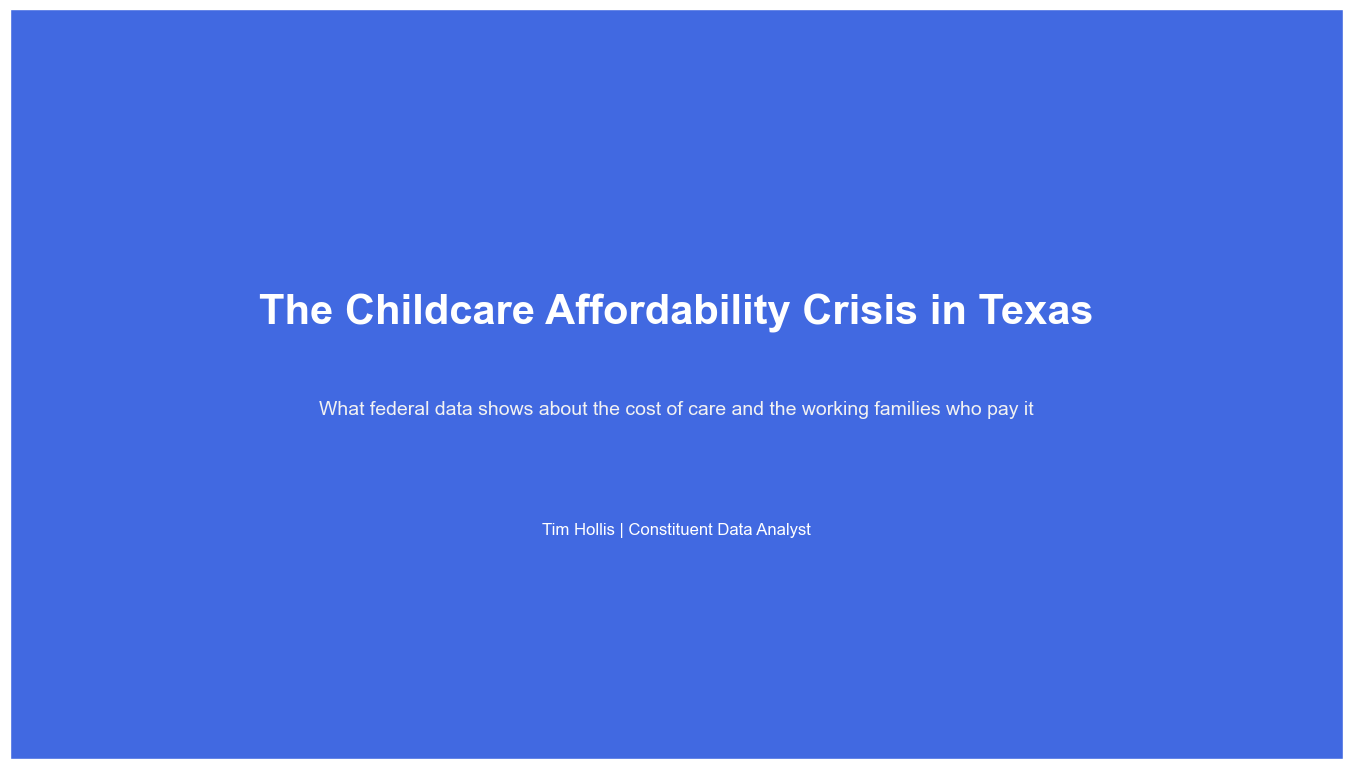

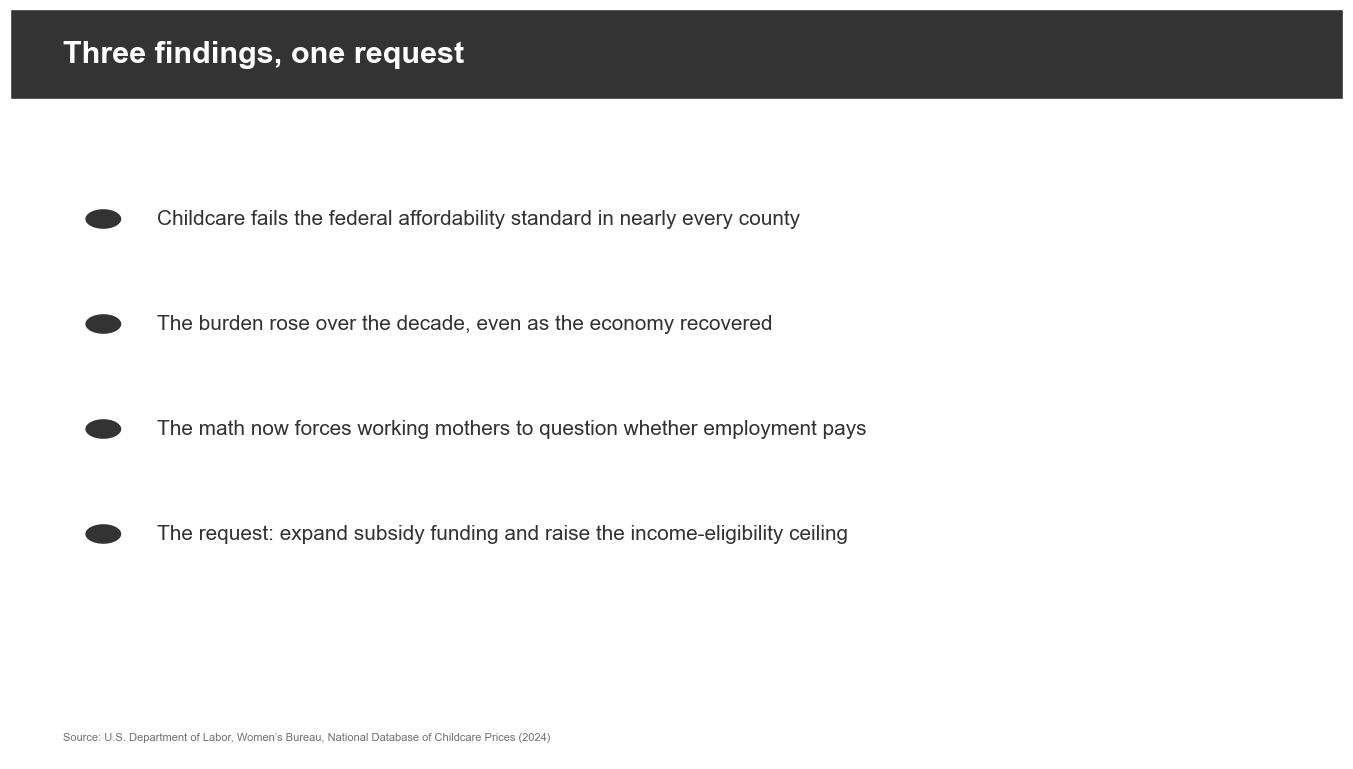

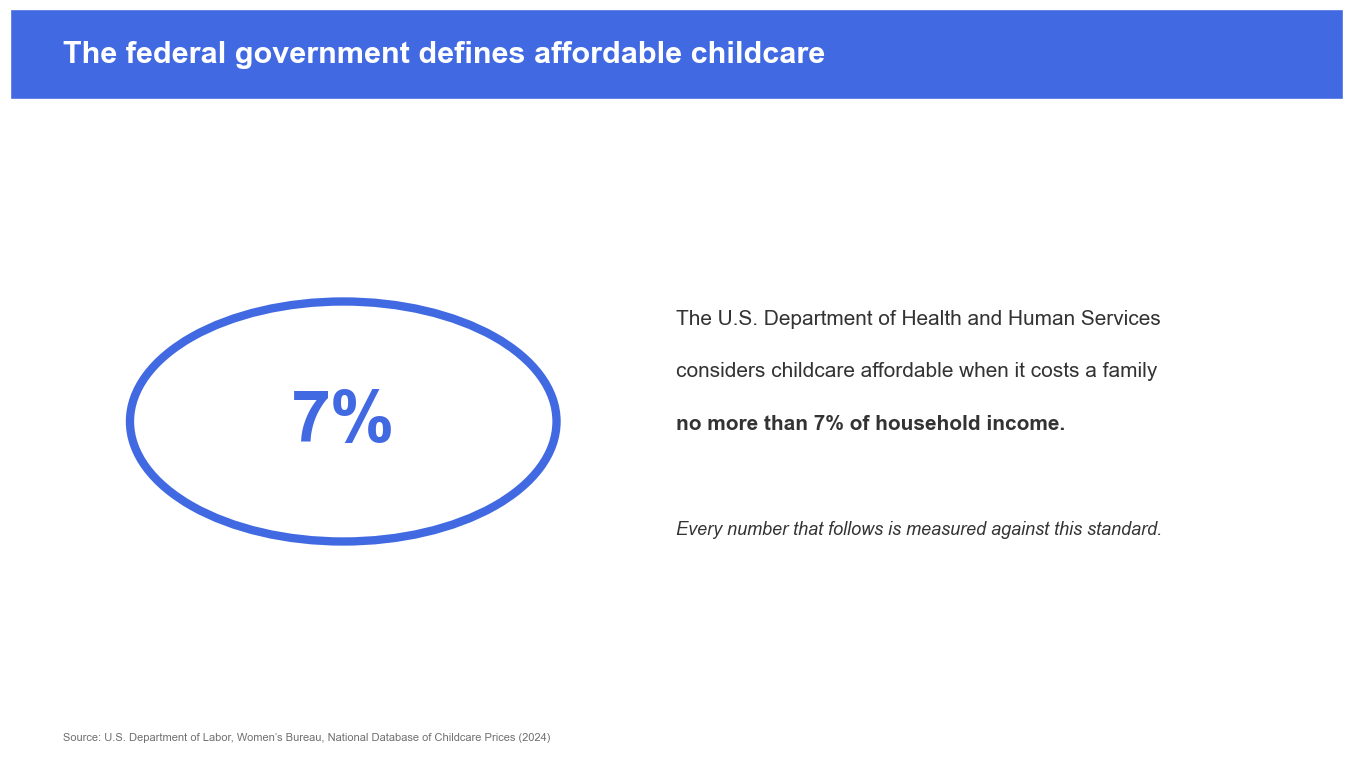

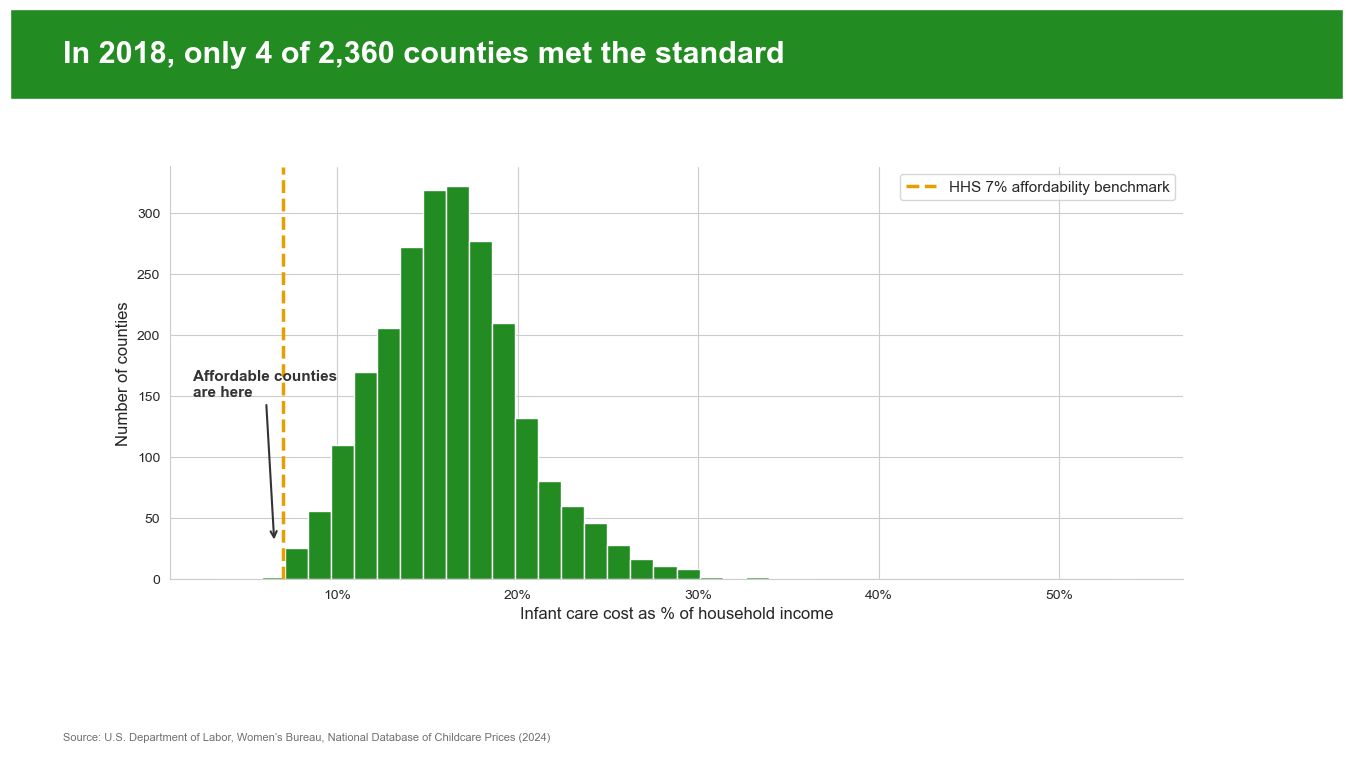

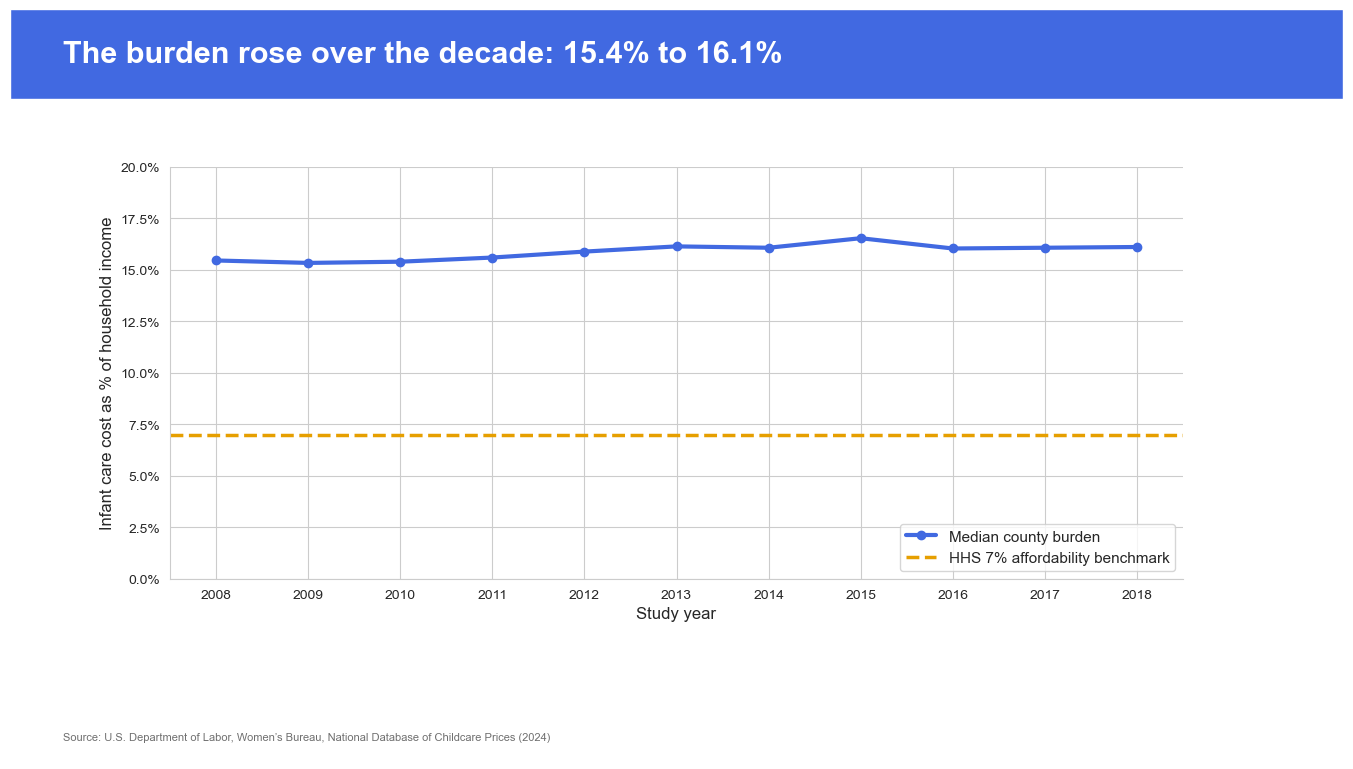

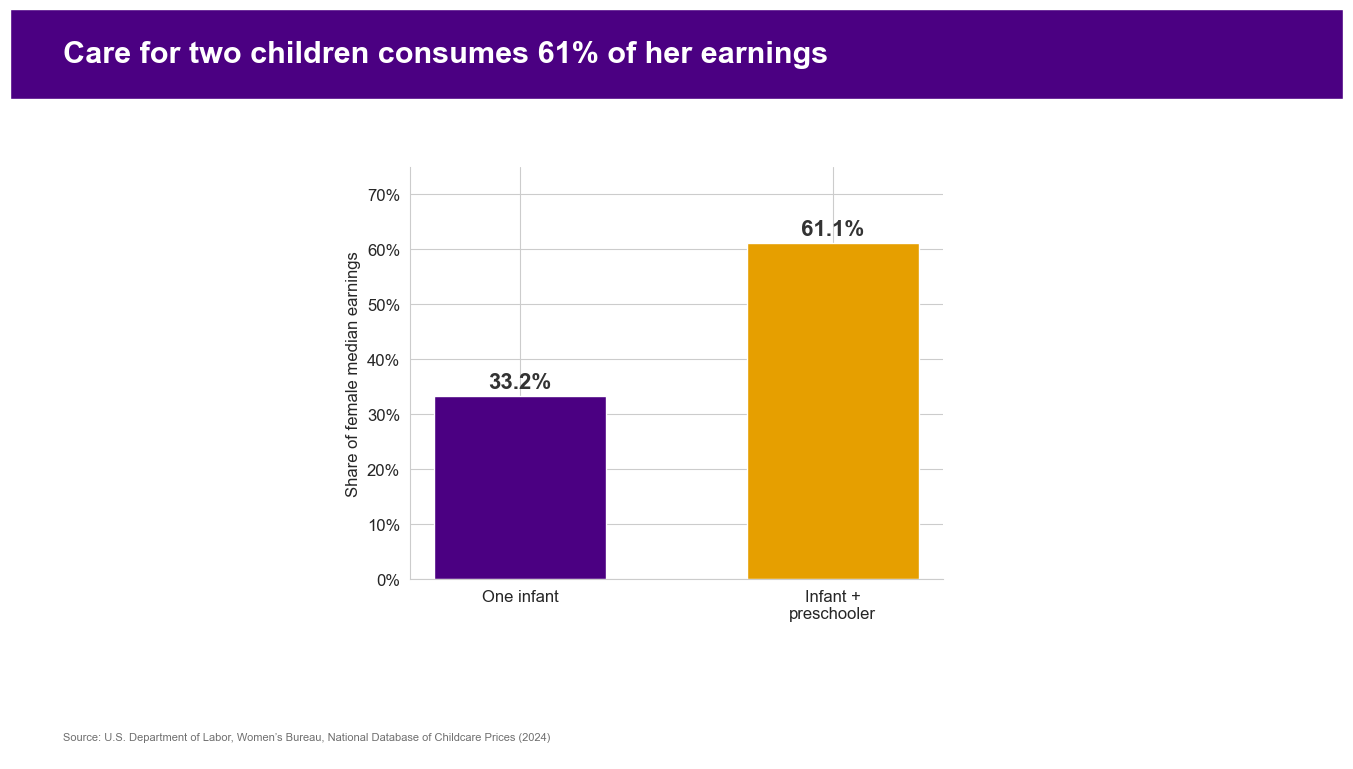

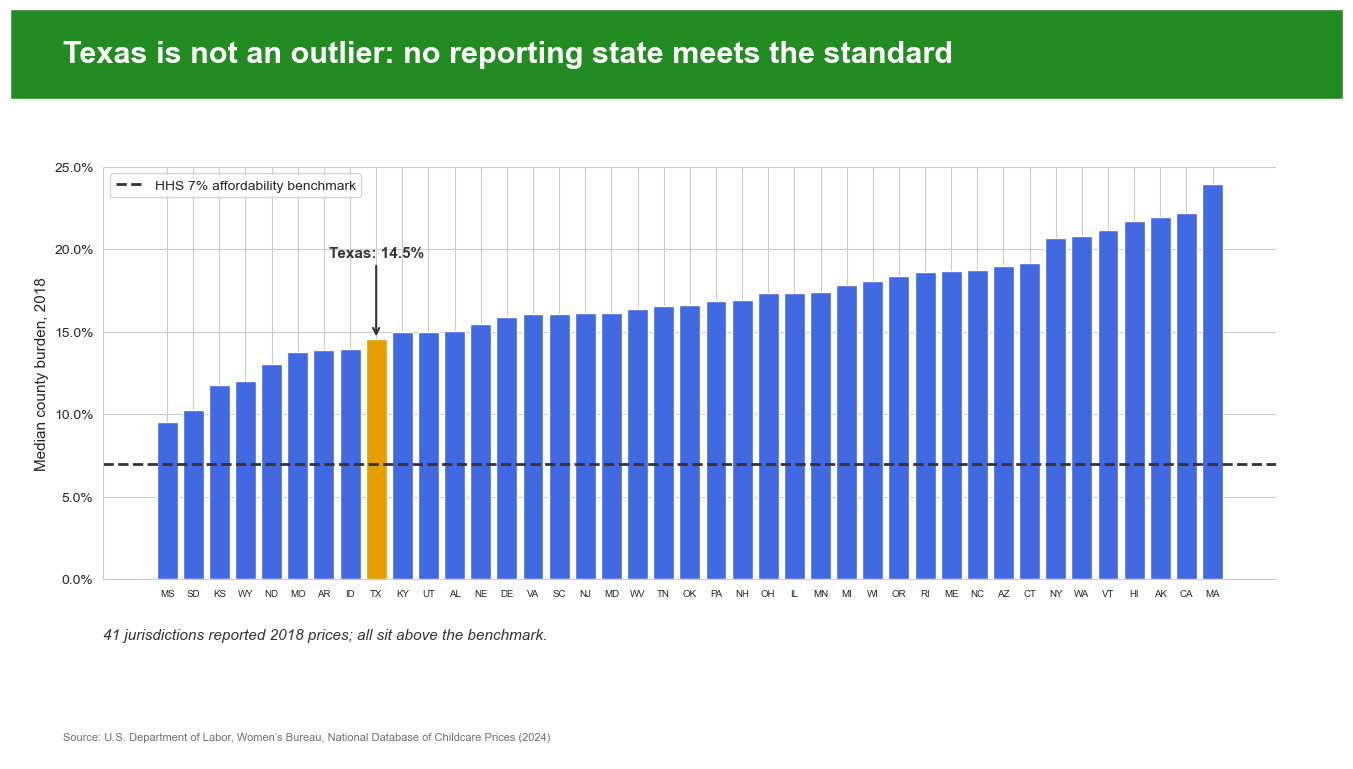

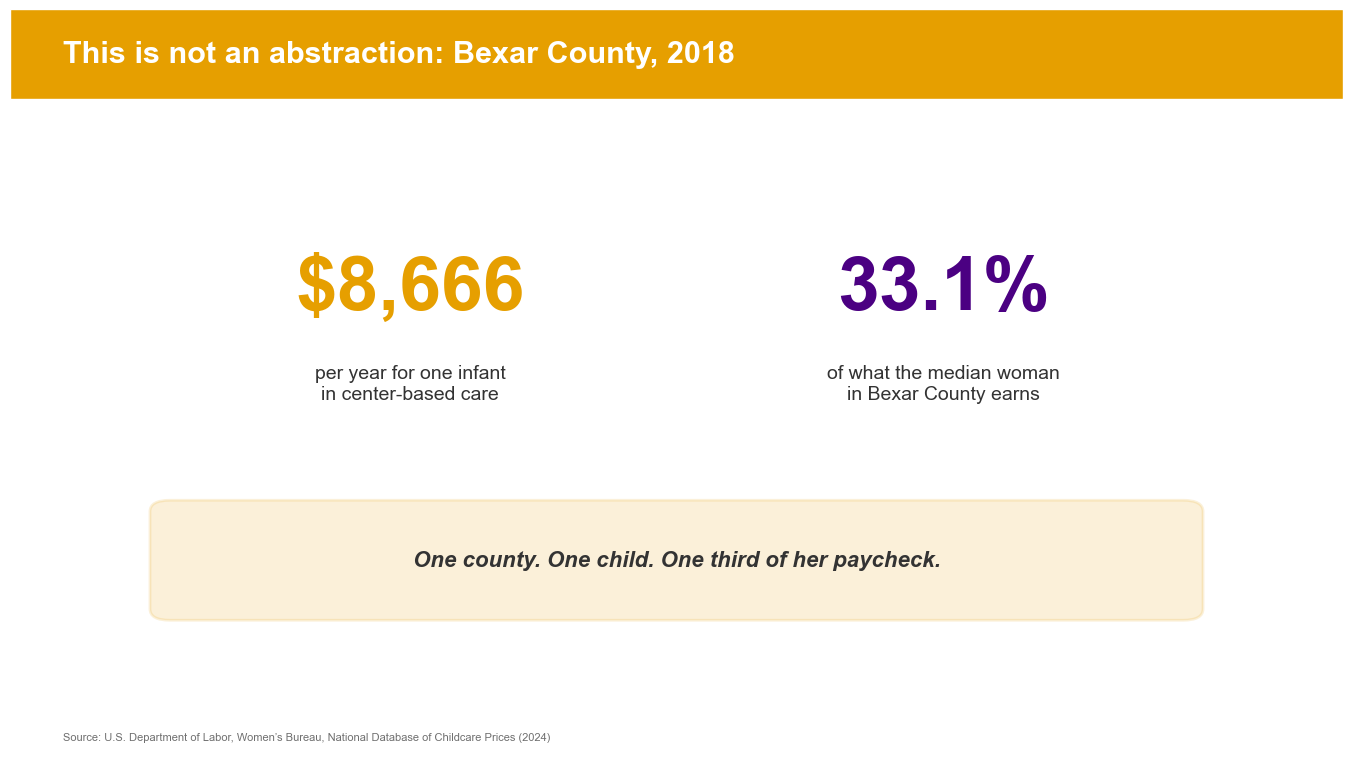

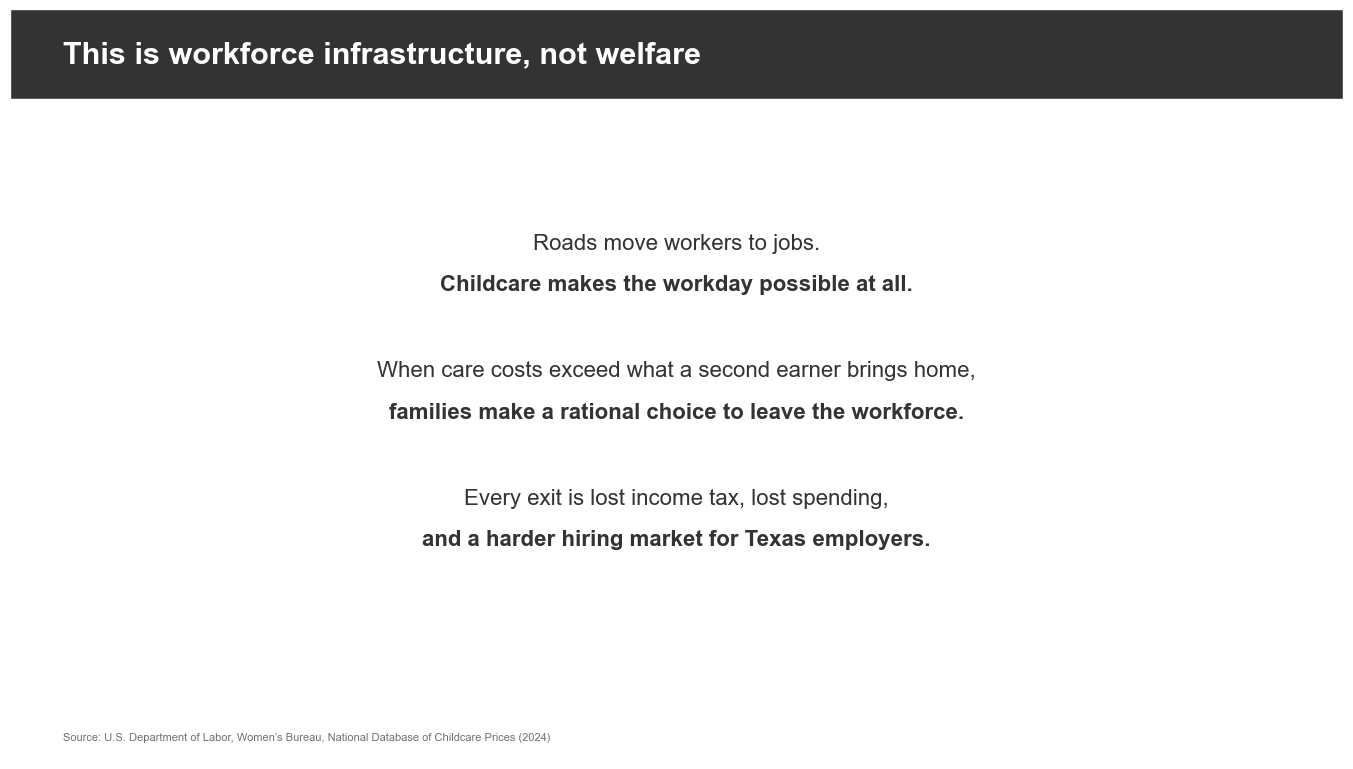

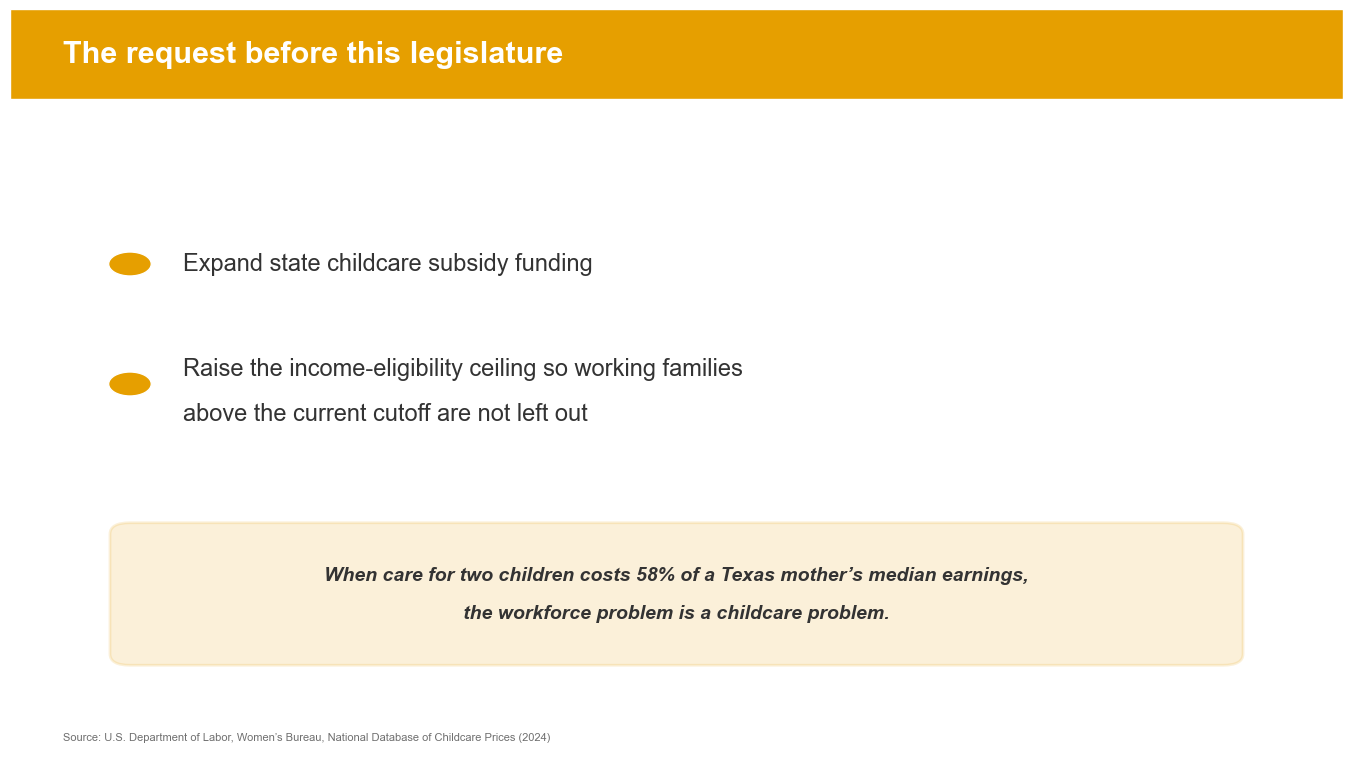

In [3]:
# Helper function for slide creation
def new_slide(accent, title_text, footer=True):
    """Creates a 16:9 slide figure with accent title bar and source footer"""
    fig = plt.figure(figsize=(13.33, 7.5))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(patches.Rectangle((0, 0.88), 1, 0.12, facecolor=accent))
    ax.text(0.04, 0.94, title_text, ha='left', va='center', fontsize=22,
            fontweight='bold', color='white')
    if footer:
        ax.text(
            0.04,
            0.025,
            SOURCE_LINE,
            fontsize=8,
            color=DARK_GRAY,
            alpha=0.7)
    return fig, ax


def clean_axes(axis):
    """Removes top and right spines from a chart axis"""
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


# Slide 1: Title
fig, ax = new_slide(ROYAL_BLUE, '', footer=False)
ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=ROYAL_BLUE))
ax.text(0.5, 0.58, 'The Childcare Affordability Crisis in Texas', ha='center',
        fontsize=30, fontweight='bold', color='white')
ax.text(
    0.5,
    0.46,
    'What federal data shows about the cost of care and the working families who pay it',
    ha='center',
    fontsize=14,
    color=LIGHT_GRAY)
ax.text(0.5, 0.3, 'Tim Hollis | Constituent Data Analyst', ha='center',
        fontsize=12, color='white')
plt.show()

# Slide 2: Roadmap
fig, ax = new_slide(DARK_GRAY, 'Three findings, one request')
roadmap = [
    'Childcare fails the federal affordability standard in nearly every county',
    'The burden rose over the decade, even as the economy recovered',
    'The math now forces working mothers to question whether employment pays',
    'The request: expand subsidy funding and raise the income-eligibility ceiling'
]
for i, item in enumerate(roadmap):
    y = 0.72 - i * 0.14
    ax.add_patch(patches.Circle((0.07, y), 0.014, facecolor=DARK_GRAY))
    ax.text(
        0.11,
        y,
        item,
        ha='left',
        va='center',
        fontsize=15,
        color=DARK_GRAY)
plt.show()

# Slide 3: The 7% standard
fig, ax = new_slide(
    ROYAL_BLUE, 'The federal government defines affordable childcare')
ax.add_patch(patches.Circle((0.25, 0.45), 0.16, facecolor='none',
                            edgecolor=ROYAL_BLUE, linewidth=6))
ax.text(0.25, 0.45, f'{BENCHMARK}%', ha='center', va='center', fontsize=52,
        fontweight='bold', color=ROYAL_BLUE)
ax.text(
    0.5,
    0.58,
    'The U.S. Department of Health and Human Services',
    fontsize=15,
    color=DARK_GRAY)
ax.text(
    0.5,
    0.51,
    'considers childcare affordable when it costs a family',
    fontsize=15,
    color=DARK_GRAY)
ax.text(
    0.5,
    0.44,
    f'no more than {BENCHMARK}% of household income.',
    fontsize=15,
    fontweight='bold',
    color=DARK_GRAY)
ax.text(
    0.5,
    0.3,
    'Every number that follows is measured against this standard.',
    fontsize=13,
    style='italic',
    color=DARK_GRAY)
plt.show()

# Slide 4: 2018 national distribution
fig, ax = new_slide(
    FOREST_GREEN, f'In 2018, only {counties_below} of {counties_total:,} counties met the standard')
ax_chart = fig.add_axes([0.12, 0.24, 0.76, 0.55])
ax_chart.hist(
    hist_2018['income_share'],
    bins=40,
    color=FOREST_GREEN,
    edgecolor='white')
ax_chart.axvline(BENCHMARK, color=AMBER, linestyle='--', linewidth=2.5,
                 label=f'HHS {BENCHMARK}% affordability benchmark')
ax_chart.set_xlabel('Infant care cost as % of household income', fontsize=12)
ax_chart.set_ylabel('Number of counties', fontsize=12)
ax_chart.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.legend(fontsize=11, loc='upper right')
ax_chart.annotate('Affordable counties\nare here', xy=(6.5, 30), xytext=(2, 150),
                  fontsize=11, color=DARK_GRAY, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color=DARK_GRAY, linewidth=1.5))
clean_axes(ax_chart)
plt.show()

# Slide 5: National decade trend
fig, ax = new_slide(
    ROYAL_BLUE, f'The burden rose over the decade: {trend.loc[2008]:.1f}% to {trend.loc[2018]:.1f}%')
ax_chart = fig.add_axes([0.12, 0.24, 0.76, 0.55])
ax_chart.plot(trend.index, trend.values, color=ROYAL_BLUE, linewidth=3,
              marker='o', markersize=6, label='Median county burden')
ax_chart.axhline(BENCHMARK, color=AMBER, linestyle='--', linewidth=2.5,
                 label=f'HHS {BENCHMARK}% affordability benchmark')
ax_chart.set_xlabel('Study year', fontsize=12)
ax_chart.set_ylabel('Infant care cost as % of household income', fontsize=12)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_ylim(0, 20)
ax_chart.set_xticks(trend.index)
ax_chart.legend(fontsize=11, loc='lower right')
clean_axes(ax_chart)
plt.show()

# Slide 6: The second-earner math
fig, ax = new_slide(
    PURPLE, f'Care for two children consumes {two_child_median:.0f}% of her earnings')
ax_chart = fig.add_axes([0.3, 0.24, 0.4, 0.55])
bars = ax_chart.bar(['One infant', 'Infant +\npreschooler'],
                    [one_child_median, two_child_median],
                    color=[PURPLE, AMBER], width=0.55)
for bar, v in zip(bars, [one_child_median, two_child_median]):
    ax_chart.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f'{v:.1f}%',
                  ha='center', fontsize=16, fontweight='bold', color=DARK_GRAY)
ax_chart.set_ylabel('Share of female median earnings', fontsize=12)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_ylim(0, 75)
ax_chart.tick_params(labelsize=12)
clean_axes(ax_chart)
plt.show()

# Slide 7: State medians, Texas in context
fig, ax = new_slide(
    FOREST_GREEN, 'Texas is not an outlier: no reporting state meets the standard')
ax_chart = fig.add_axes([0.07, 0.24, 0.88, 0.55])
bar_colors = [AMBER if s ==
              'TX' else ROYAL_BLUE for s in state_medians_2018.index]
ax_chart.bar(
    state_medians_2018.index,
    state_medians_2018.values,
    color=bar_colors)
ax_chart.axhline(BENCHMARK, color=DARK_GRAY, linestyle='--', linewidth=2,
                 label=f'HHS {BENCHMARK}% affordability benchmark')
ax_chart.set_ylabel('Median county burden, 2018', fontsize=11)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_ylim(0, 25)
ax_chart.tick_params(axis='x', labelsize=7)
ax_chart.tick_params(axis='y', labelsize=10)
ax_chart.legend(fontsize=10, loc='upper left')
tx_rank = list(state_medians_2018.index).index('TX') + 1
ax_chart.annotate(f'Texas: {tx_median_share:.1f}%',
                  xy=(tx_rank - 1,
                      tx_median_share),
                  xytext=(tx_rank - 1,
                          tx_median_share + 5),
                  ha='center',
                  fontsize=11,
                  fontweight='bold',
                  color=DARK_GRAY,
                  arrowprops=dict(arrowstyle='->',
                                  color=DARK_GRAY,
                                  linewidth=1.5))
clean_axes(ax_chart)
ax.text(
    0.07,
    0.16,
    f'{len(state_medians_2018)} jurisdictions reported 2018 prices; all sit above the benchmark.',
    fontsize=11,
    style='italic',
    color=DARK_GRAY)
plt.show()

# Slide 8: Bexar County callout
fig, ax = new_slide(AMBER, 'This is not an abstraction: Bexar County, 2018')
ax.text(0.3, 0.6, f'${bexar["annual_infant_cost"]:,.0f}', ha='center',
        fontsize=54, fontweight='bold', color=AMBER)
ax.text(
    0.3,
    0.48,
    'per year for one infant\nin center-based care',
    ha='center',
    fontsize=14,
    color=DARK_GRAY)
ax.text(0.7, 0.6, f'{bexar["one_child_share"]:.1f}%', ha='center',
        fontsize=54, fontweight='bold', color=PURPLE)
ax.text(
    0.7,
    0.48,
    'of what the median woman\nin Bexar County earns',
    ha='center',
    fontsize=14,
    color=DARK_GRAY)
ax.add_patch(
    patches.FancyBboxPatch(
        (0.12,
         0.2),
        0.76,
        0.13,
        boxstyle='round,pad=0.015',
        facecolor=AMBER,
        alpha=0.15,
        edgecolor=AMBER,
        linewidth=2))
ax.text(0.5, 0.265, 'One county. One child. One third of her paycheck.',
        ha='center', va='center', fontsize=16, style='italic',
        fontweight='bold', color=DARK_GRAY)
plt.show()

# Slide 9: Reframe
fig, ax = new_slide(DARK_GRAY, 'This is workforce infrastructure, not welfare')
reframe = [('Roads move workers to jobs.',
            'Childcare makes the workday possible at all.'),
           ('When care costs exceed what a second earner brings home,',
            'families make a rational choice to leave the workforce.'),
           ('Every exit is lost income tax, lost spending,',
            'and a harder hiring market for Texas employers.')]
for i, (line1, line2) in enumerate(reframe):
    y = 0.68 - i * 0.17
    ax.text(0.5, y, line1, ha='center', fontsize=16, color=DARK_GRAY)
    ax.text(
        0.5,
        y - 0.055,
        line2,
        ha='center',
        fontsize=16,
        fontweight='bold',
        color=DARK_GRAY)
plt.show()

# Slide 10: The ask
fig, ax = new_slide(AMBER, 'The request before this legislature')

ax.add_patch(patches.Circle((0.09, 0.66), 0.016, facecolor=AMBER, zorder=3))
ax.text(0.13, 0.66, 'Expand state childcare subsidy funding',
        ha='left', va='center', fontsize=17, color=DARK_GRAY, zorder=4)

ax.add_patch(patches.Circle((0.09, 0.50), 0.016, facecolor=AMBER, zorder=3))
ax.text(0.13, 0.52, 'Raise the income-eligibility ceiling so working families',
        ha='left', va='center', fontsize=17, color=DARK_GRAY, zorder=4)
ax.text(0.13, 0.46, 'above the current cutoff are not left out',
        ha='left', va='center', fontsize=17, color=DARK_GRAY, zorder=4)

ax.add_patch(patches.FancyBboxPatch((0.09, 0.14), 0.82, 0.16,
                                    boxstyle='round,pad=0.015',
                                    facecolor=AMBER, alpha=0.15,
                                    edgecolor=AMBER, linewidth=2, zorder=2))
closing_line1 = f'When care for two children costs {tx_two_child:.0f}% of a Texas mother\u2019s median earnings,'
closing_line2 = 'the workforce problem is a childcare problem.'
ax.text(0.5, 0.245, closing_line1, ha='center', va='center', fontsize=14,
        style='italic', fontweight='bold', color=DARK_GRAY, zorder=4)
ax.text(0.5, 0.195, closing_line2, ha='center', va='center', fontsize=14,
        style='italic', fontweight='bold', color=DARK_GRAY, zorder=4)
plt.show()

<div style="page-break-after: always;"></div>

### **Power BI Dashboard**

The dashboard is the only medium that works at county-level granularity. Where the deck aggregates to national and state medians, this view keeps all 254 Texas counties visible: every county plotted individually, price against income, the spread within each reporting year, and the ten counties carrying the heaviest burden. No chart type or data cut here appears in the deck or the infographic.

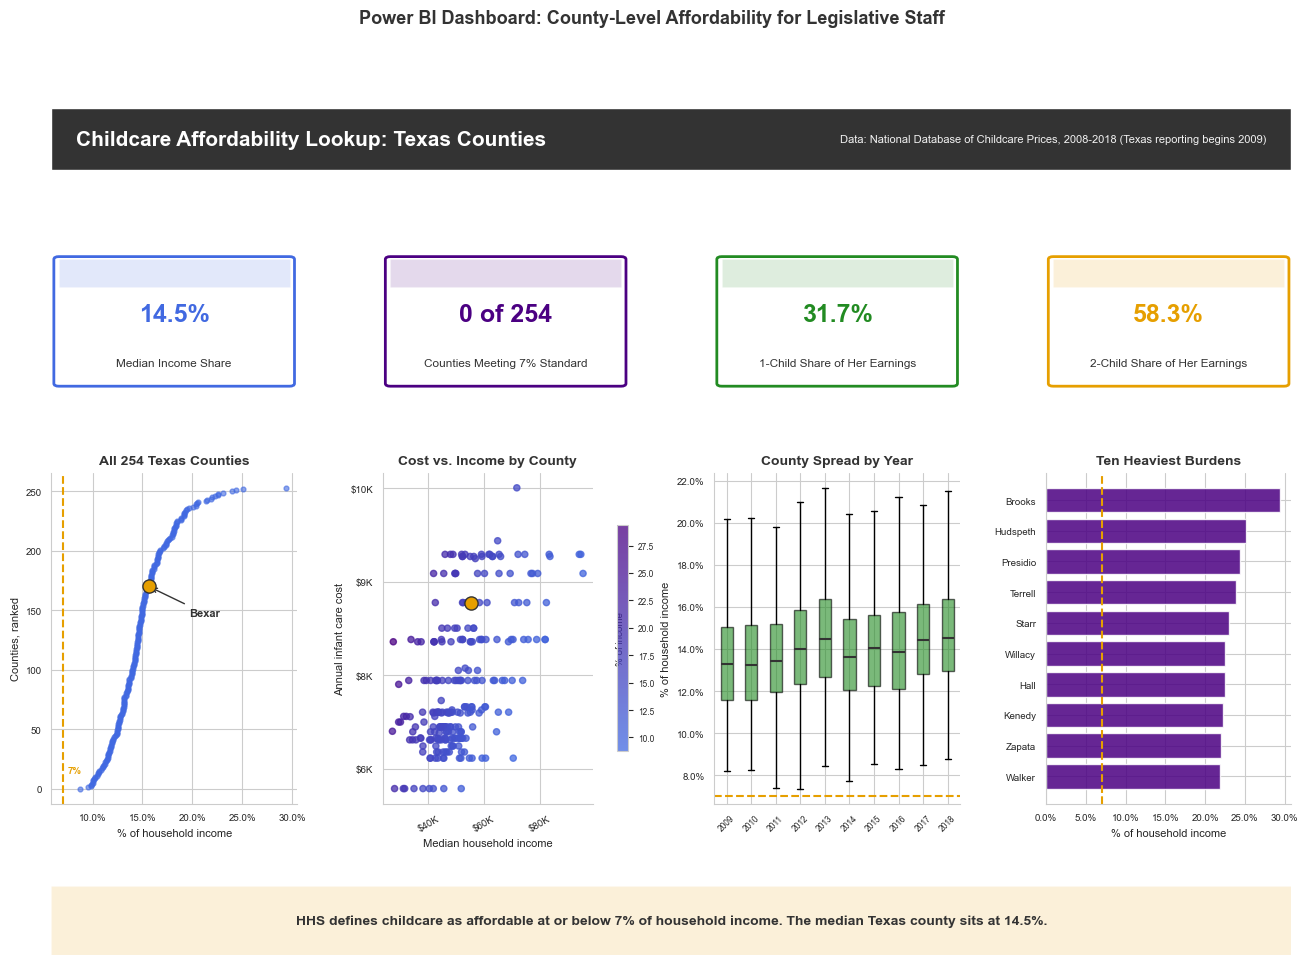

✅ Dashboard complete: 4 county-level panels covering 254 Texas counties


In [4]:
# Create dashboard
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(
    4,
    4,
    height_ratios=[
        0.45,
        1.0,
        2.4,
        0.5],
    hspace=0.55,
    wspace=0.35)

# Title bar
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=DARK_GRAY))
ax_title.text(
    0.02,
    0.5,
    'Childcare Affordability Lookup: Texas Counties',
    ha='left',
    va='center',
    fontsize=15,
    fontweight='bold',
    color='white')
ax_title.text(
    0.98,
    0.5,
    'Data: National Database of Childcare Prices, 2008-2018 (Texas reporting begins 2009)',
    ha='right',
    va='center',
    fontsize=8,
    color=LIGHT_GRAY)
ax_title.axis('off')

# KPI strip - Texas statewide default view
kpis = [
    ('Median Income Share', f'{tx_median_share:.1f}%', ROYAL_BLUE),
    ('Counties Meeting 7% Standard', f'{tx_counties_below} of {tx_counties_total}', PURPLE),
    ('1-Child Share of Her Earnings', f'{tx_one_child:.1f}%', FOREST_GREEN),
    ('2-Child Share of Her Earnings', f'{tx_two_child:.1f}%', AMBER),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(
        patches.FancyBboxPatch(
            (0.03,
             0.05),
            0.94,
            0.9,
            boxstyle='round,pad=0.02',
            facecolor='white',
            edgecolor=color,
            linewidth=2))
    ax.add_patch(
        patches.Rectangle(
            (0.03,
             0.75),
            0.94,
            0.2,
            facecolor=color,
            alpha=0.15))
    ax.text(0.5, 0.55, value, ha='center', va='center', fontsize=18,
            fontweight='bold', color=color)
    ax.text(
        0.5,
        0.2,
        label,
        ha='center',
        va='center',
        fontsize=8.5,
        color=DARK_GRAY)
    ax.axis('off')

# Panel 1: every Texas county plotted individually
ax_strip = fig.add_subplot(gs[2, 0])
tx_sorted = tx_2018.sort_values('income_share').reset_index(drop=True)
bexar_pos = tx_sorted.index[tx_sorted['county'] == 'Bexar County'][0]
ax_strip.scatter(tx_sorted['income_share'], tx_sorted.index,
                 color=ROYAL_BLUE, s=12, alpha=0.6)
ax_strip.scatter(tx_sorted.loc[bexar_pos, 'income_share'], bexar_pos,
                 color=AMBER, s=90, zorder=5, edgecolor=DARK_GRAY, linewidth=1)
ax_strip.axvline(BENCHMARK, color=AMBER, linestyle='--', linewidth=1.5)
ax_strip.text(BENCHMARK + 0.5, tx_counties_total * 0.05, f'{BENCHMARK}%',
              fontsize=7, color=AMBER, fontweight='bold')
ax_strip.annotate('Bexar',
                  xy=(tx_sorted.loc[bexar_pos,
                      'income_share'],
                      bexar_pos),
                  xytext=(tx_sorted.loc[bexar_pos,
                          'income_share'] + 4,
                          bexar_pos - 25),
                  fontsize=8,
                  fontweight='bold',
                  color=DARK_GRAY,
                  arrowprops=dict(arrowstyle='->',
                                  color=DARK_GRAY,
                                  linewidth=1))
ax_strip.set_title(f'All {tx_counties_total} Texas Counties', fontsize=10,
                   fontweight='bold', color=DARK_GRAY)
ax_strip.set_xlabel('% of household income', fontsize=8)
ax_strip.set_ylabel('Counties, ranked', fontsize=8)
ax_strip.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_strip.tick_params(labelsize=7)
clean_axes(ax_strip)

# Panel 2: price against income
ax_scatter = fig.add_subplot(gs[2, 1])
scatter_points = ax_scatter.scatter(
    tx_2018['nominal_income'],
    tx_2018['annual_infant_cost'],
    c=tx_2018['income_share'],
    cmap=PROJECT_CMAP,
    s=20,
    alpha=0.75)
ax_scatter.scatter(
    bexar['nominal_income'],
    bexar['annual_infant_cost'],
    color=AMBER,
    s=90,
    zorder=5,
    edgecolor=DARK_GRAY,
    linewidth=1)
cbar = fig.colorbar(scatter_points, ax=ax_scatter, fraction=0.046, pad=0.10)
cbar.set_label('% of income', fontsize=7, labelpad=-28)
cbar.ax.tick_params(labelsize=6)
ax_scatter.set_title('Cost vs. Income by County', fontsize=10,
                     fontweight='bold', color=DARK_GRAY)
ax_scatter.set_xlabel('Median household income', fontsize=8)
ax_scatter.set_ylabel('Annual infant care cost', fontsize=8)
ax_scatter.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
ax_scatter.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax_scatter.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, p: f'${v / 1000:,.0f}K'))
ax_scatter.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, p: f'${v / 1000:,.0f}K'))
ax_scatter.tick_params(axis='x', labelsize=7, rotation=30)
ax_scatter.tick_params(axis='y', labelsize=7)
clean_axes(ax_scatter)

# Panel 3: spread within each year
ax_box = fig.add_subplot(gs[2, 2])
years_present = sorted(tx_all['year'].unique())
box_data = [tx_all[tx_all['year'] == y]['income_share'].dropna()
            for y in years_present]
bp = ax_box.boxplot(
    box_data,
    tick_labels=years_present,
    patch_artist=True,
    showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(FOREST_GREEN)
    patch.set_alpha(0.6)
for median in bp['medians']:
    median.set_color(DARK_GRAY)
    median.set_linewidth(1.5)
ax_box.axhline(BENCHMARK, color=AMBER, linestyle='--', linewidth=1.5)
ax_box.set_title(
    'County Spread by Year',
    fontsize=10,
    fontweight='bold',
    color=DARK_GRAY)
ax_box.set_ylabel('% of household income', fontsize=8)
ax_box.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_box.tick_params(axis='x', labelsize=6, rotation=45)
ax_box.tick_params(axis='y', labelsize=7)
clean_axes(ax_box)

# Panel 4: heaviest burden counties
ax_top = fig.add_subplot(gs[2, 3])
top_sorted = tx_top10.sort_values('income_share')
ax_top.barh(top_sorted['county'].str.replace(' County', '', regex=False),
            top_sorted['income_share'], color=PURPLE, alpha=0.85)
ax_top.axvline(BENCHMARK, color=AMBER, linestyle='--', linewidth=1.5)
ax_top.set_title(
    'Ten Heaviest Burdens',
    fontsize=10,
    fontweight='bold',
    color=DARK_GRAY)
ax_top.set_xlabel('% of household income', fontsize=8)
ax_top.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_top.tick_params(labelsize=7)
clean_axes(ax_top)

# Benchmark footer strip
ax_footer = fig.add_subplot(gs[3, :])
ax_footer.set_xlim(0, 1)
ax_footer.set_ylim(0, 1)
ax_footer.add_patch(patches.Rectangle(
    (0, 0), 1, 1, facecolor=AMBER, alpha=0.15))
footer_text = f'HHS defines childcare as affordable at or below {BENCHMARK}% of household income. The median Texas county sits at {tx_median_share:.1f}%.'
ax_footer.text(0.5, 0.5, footer_text, ha='center', va='center', fontsize=10,
               color=DARK_GRAY, fontweight='bold')
ax_footer.axis('off')

fig.suptitle(
    'Power BI Dashboard: County-Level Affordability for Legislative Staff',
    fontsize=13,
    fontweight='bold',
    color=DARK_GRAY,
    y=0.97)
plt.show()

print(
    f'✅ Dashboard complete: 4 county-level panels covering {tx_counties_total} Texas counties')

<div style="page-break-after: always;"></div>

### **Infographic**

The infographic uses no conventional chart. Its three visuals are pictorial: an icon array standing in for all 254 Texas counties, a part-to-whole bar showing what remains of a mother's earnings after care, and a bullet chart measuring the Texas median against the benchmark. None of these forms appears in the deck or the dashboard, and the page carries only Texas figures.

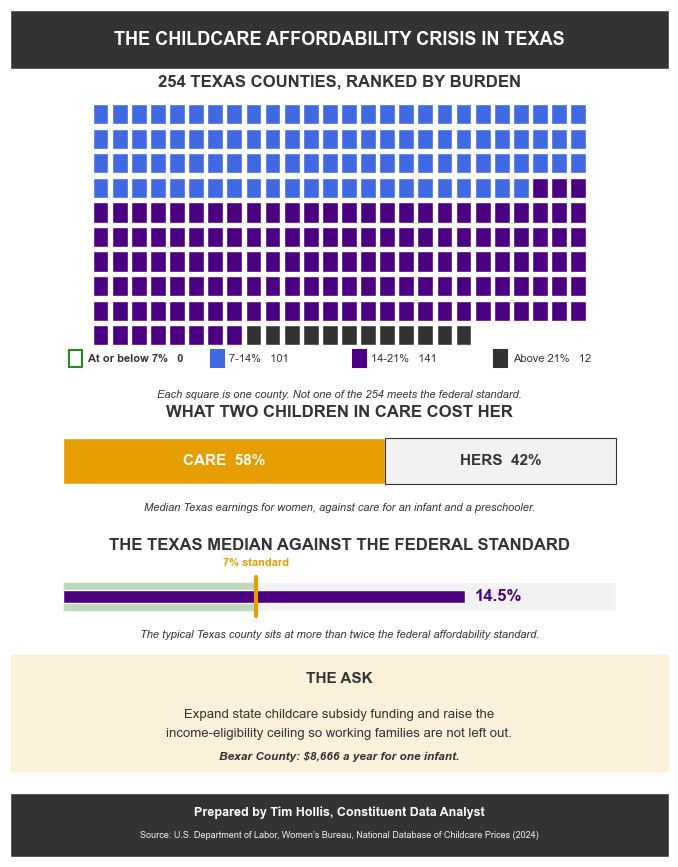

✅ Infographic complete: icon array, part-to-whole bar, and bullet chart, all Texas figures


In [5]:
# Create infographic
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Header band
ax.add_patch(patches.Rectangle((0, 0.93), 1, 0.07, facecolor=DARK_GRAY))
ax.text(
    0.5,
    0.965,
    'THE CHILDCARE AFFORDABILITY CRISIS IN TEXAS',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='white')

# Visual 1: icon array, one square per Texas county, shaded by burden
ax.text(
    0.5,
    0.915,
    f'{tx_counties_total} TEXAS COUNTIES, RANKED BY BURDEN',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color=DARK_GRAY)

tier_bounds = [(0, BENCHMARK, FOREST_GREEN, f'At or below {BENCHMARK}%'),
               (BENCHMARK, 14, ROYAL_BLUE, f'{BENCHMARK}-14%'),
               (14, 21, PURPLE, '14-21%'),
               (21, 999, DARK_GRAY, 'Above 21%')]


def tier_for(share):
    """Returns the palette color matching a county's income share"""
    for low, high, color, label in tier_bounds:
        if low <= share < high:
            return color
    return DARK_GRAY


grid_counties = tx_2018.sort_values('income_share').reset_index(drop=True)
cols = 26
cell, gap = 0.024, 0.005
grid_w = cols * cell + (cols - 1) * gap
x_start = (1 - grid_w) / 2
y_start = 0.865
for i, share in enumerate(grid_counties['income_share']):
    r, c = divmod(i, cols)
    x = x_start + c * (cell + gap)
    y = y_start - r * (cell + gap)
    ax.add_patch(
        patches.Rectangle(
            (x, y), cell, cell, facecolor=tier_for(share)))

# Legend, including the empty affordable tier
legend_y = 0.578
swatch = 0.020
legend_x = 0.09
for low, high, color, label in tier_bounds:
    count = int(((grid_counties['income_share'] >= low)
                 & (grid_counties['income_share'] < high)).sum())
    ax.add_patch(patches.Rectangle((legend_x, legend_y), swatch, swatch,
                                   facecolor=color if count else 'white',
                                   edgecolor=color, linewidth=1.5))
    ax.text(legend_x + swatch + 0.008, legend_y + swatch / 2,
            f'{label}   {count}', ha='left', va='center',
            fontsize=8, fontweight='bold' if count == 0 else 'normal',
            color=DARK_GRAY)
    legend_x += 0.215

ax.text(
    0.5,
    0.545,
    f'Each square is one county. Not one of the {tx_counties_total} meets the federal standard.',
    ha='center',
    va='center',
    fontsize=8,
    style='italic',
    color=DARK_GRAY)

# Visual 2: what is left of her earnings
bar_y, bar_h = 0.44, 0.055
ax.text(0.5, 0.525, 'WHAT TWO CHILDREN IN CARE COST HER', ha='center',
        va='center', fontsize=12, fontweight='bold', color=DARK_GRAY)
care_frac = tx_two_child / 100
ax.add_patch(patches.Rectangle((0.08, bar_y), 0.84 * care_frac, bar_h,
                               facecolor=AMBER))
ax.add_patch(patches.Rectangle((0.08 + 0.84 * care_frac, bar_y),
                               0.84 * (1 - care_frac), bar_h,
                               facecolor=LIGHT_GRAY, edgecolor=DARK_GRAY, linewidth=0.8))
ax.text(0.08 + 0.84 * care_frac / 2, bar_y + bar_h / 2,
        f'CARE  {tx_two_child:.0f}%', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')
ax.text(0.08 + 0.84 * care_frac + 0.84 * (1 - care_frac) / 2,
        bar_y + bar_h / 2,
        f'HERS  {100 - tx_two_child:.0f}%',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color=DARK_GRAY)
ax.text(
    0.5,
    0.412,
    'Median Texas earnings for women, against care for an infant and a preschooler.',
    ha='center',
    va='center',
    fontsize=8,
    style='italic',
    color=DARK_GRAY)

# Visual 3: bullet chart against the benchmark
bullet_y, bullet_h = 0.29, 0.035
scale_max = 20
ax.text(
    0.5,
    0.368,
    'THE TEXAS MEDIAN AGAINST THE FEDERAL STANDARD',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color=DARK_GRAY)
ax.add_patch(patches.Rectangle((0.08, bullet_y), 0.84, bullet_h,
                               facecolor=LIGHT_GRAY))
ax.add_patch(patches.Rectangle((0.08, bullet_y), 0.84 * (BENCHMARK /
             scale_max), bullet_h, facecolor=FOREST_GREEN, alpha=0.25))
ax.add_patch(patches.Rectangle((0.08, bullet_y + bullet_h * 0.28),
                               0.84 * (tx_median_share / scale_max), bullet_h * 0.44,
                               facecolor=PURPLE, zorder=4))
bench_x = 0.08 + 0.84 * (BENCHMARK / scale_max)
ax.plot([bench_x, bench_x], [bullet_y - 0.006, bullet_y + bullet_h + 0.006],
        color=AMBER, linewidth=3, zorder=6)
ax.text(bench_x, bullet_y + bullet_h + 0.018, f'{BENCHMARK}% standard',
        ha='center', fontsize=8, fontweight='bold', color=AMBER)
ax.text(0.08 + 0.84 * (tx_median_share / scale_max) + 0.015,
        bullet_y + bullet_h / 2,
        f'{tx_median_share:.1f}%',
        ha='left',
        va='center',
        fontsize=12,
        fontweight='bold',
        color=PURPLE)
ax.text(
    0.5,
    0.262,
    'The typical Texas county sits at more than twice the federal affordability standard.',
    ha='center',
    va='center',
    fontsize=8,
    style='italic',
    color=DARK_GRAY)

# Call to action strip
ax.add_patch(
    patches.Rectangle(
        (0,
         0.10),
        1,
        0.14,
        facecolor=AMBER,
        alpha=0.15))
ax.text(0.5, 0.205, 'THE ASK', ha='center', fontsize=11,
        fontweight='bold', color=DARK_GRAY)
ax.text(0.5, 0.168, 'Expand state childcare subsidy funding and raise the',
        ha='center', va='center', fontsize=9.5, color=DARK_GRAY)
ax.text(
    0.5,
    0.145,
    'income-eligibility ceiling so working families are not left out.',
    ha='center',
    va='center',
    fontsize=9.5,
    color=DARK_GRAY)
ax.text(
    0.5,
    0.118,
    f'Bexar County: ${bexar["annual_infant_cost"]:,.0f} a year for one infant.',
    ha='center',
    va='center',
    fontsize=8.5,
    style='italic',
    fontweight='bold',
    color=DARK_GRAY)

# Footer
ax.add_patch(patches.Rectangle((0, 0), 1, 0.075, facecolor=DARK_GRAY))
ax.text(0.5, 0.048, 'Prepared by Tim Hollis, Constituent Data Analyst',
        ha='center', fontsize=9, color='white', fontweight='bold')
ax.text(0.5, 0.022, SOURCE_LINE, ha='center', fontsize=6.5, color=LIGHT_GRAY)
plt.show()

print(f'✅ Infographic complete: icon array, part-to-whole bar, and bullet chart, all Texas figures')

<div style="page-break-after: always;"></div>

---

# The Childcare Affordability Crisis in Texas

## Summary of Analysis

The national database of childcare prices (U.S. Department of Labor, Women's Bureau, 2024) contains 34,567 county-year records spanning 2008 through 2018 across 51 jurisdictions, with 227 columns covering prices, labor force measures, earnings, and demographics. Working in Python, I narrowed the file to identifiers, median weekly center-based infant and preschool prices, median household income, and female median earnings. I annualized the weekly prices at 52 weeks and measured the result against the U.S. Department of Health and Human Services standard that childcare is affordable when it costs no more than 7% of household income. That standard is the reference line for every figure in every medium.

## Findings

Four findings anchor the final story. First, childcare fails the federal standard almost universally. In 2018, only 4 of 2,360 reporting counties nationwide came in at or below 7%, the median county spent 16.1% of household income on care for a single infant, and zero of 254 Texas counties met the standard.

Second, the burden grew across the decade. Nationally the median county moved from 15.4% in 2008 to 16.1% in 2018, and in Texas from 13.3% in 2009 to 14.5% in 2018, even as the broader economy recovered.

Third, the household math is severe. One infant in center-based care consumes 33.2% of female median earnings in the typical county and 31.7% in Texas, while an infant and a preschooler together consume 61.1% nationally and 58.3% in Texas. Bexar County sits at $8,666 per year for infant care, or 33.1% of female median earnings.

Fourth, and new to this milestone, the Texas failure is not a near miss concentrated at the margin. Of the 254 Texas counties, 101 fall between 7% and 14% of household income, 141 fall between 14% and 21%, and 12 exceed 21%. The largest group of counties sits at two to three times the federal standard rather than just above it.

I also tested care burden against labor force participation among mothers of young children and found essentially no relationship (r = -0.04). I report that null result rather than omit it, and I removed the participation claim from the story it did not support.

## Assumptions

I assumed that median center-based prices represent the typical family's cost, that care is purchased full time for 52 weeks per year, and that nominal prices should be compared against nominal income within the same year. Female median earnings include part-time workers, which raises the earnings-share figures above what they would be if measured against full-time salaries. Counties are identified by FIPS code rather than name, since county names repeat across states.

## Items Needing Clarification

Roughly a third of price values are missing across the full file, and reporting coverage grew from 1,424 counties in 2008 to 2,360 in 2018, so any trend statement must be read alongside changing coverage. Texas reporting does not begin until 2009. Only 41 of the 51 jurisdictions reported 2018 prices at all, which limits the state comparison to those 41. The dataset flags imputed values, and I have not quantified how much of each visual rests on modeled rather than observed prices. Establishing whether high prices push mothers out of the workforce would require within-county longitudinal analysis. The data ends in 2018, so it predates the pandemic and every price shock since.

<div style="page-break-after: always;"></div>

## Direction of Story and Target Audience

The story is persuasive rather than informational. Childcare in Texas fails the federal government's own affordability standard everywhere it is measured, the burden is growing, and the household math now forces families to weigh whether a second income still pays for itself. The ask is specific: expand state childcare subsidy funding and raise the income-eligibility ceiling so that working families above the current cutoff but far below affordability are not left out.

The audience is Texas state legislators and their staff. They are policy literate but not data literate, and they carry a fiscal skepticism toward new spending that the story has to earn its way past rather than ignore. My role is a constituent data analyst presenting verified federal data, which gives me credibility without requiring an institutional affiliation. The story counters the spending bias by framing childcare as workforce infrastructure rather than welfare, since that reframe determines whether the request is heard or dismissed.

## Mediums Included and Why

Three mediums carry the story at three speeds, and each now carries its own set of visuals rather than resized copies of a shared set.

The PowerPoint briefing deck is the slow version. It argues at national scale, walking a legislator through the federal standard, the 2018 distribution, the decade trend, the second-earner comparison, and state-level medians before the ask appears. Its four charts are all national or state aggregates.

The Power BI dashboard is the self-serve version and the only medium working at county-level granularity. Its four panels plot all 254 Texas counties individually, chart cost against income for each county, show the spread of counties within each reporting year, and rank the ten heaviest burdens by name.

The one-page infographic is the fast version and uses no conventional chart at all. An icon array gives one square to each Texas county shaded by burden tier, a part-to-whole bar shows what remains of a mother's earnings after care for two children, and a bullet chart measures the Texas median against the benchmark.

## Design Decisions

The governing rule for this final version was that no chart type and no data cut may appear in more than one medium. That rule came directly from the Milestone 3 feedback, and applying it changed real content. The Texas trend line, which had appeared in all three mediums, now appears in none of them. The deck's Texas slide became a ranked state comparison, its Bexar slide became a numeric callout with no chart, and the dashboard's mock county selector and map placeholder were removed because with real data on the page they read as unfinished rather than interactive.

All three mediums share one colorblind-safe palette, with amber reserved exclusively for the 7% benchmark so the standard reads as the same object in every artifact. Slide titles are written as complete claims rather than topic labels, so a slide forwarded in isolation still argues something. Axes are zero-based so the gap above the benchmark is not visually exaggerated.

The most effective single decision was the infographic's icon array. An earlier version drew 254 identical squares, which required the reader to trust the caption because a uniform grid shows no contrast. Shading each square by burden tier and including an affordable tier in the legend with a count of zero made the absence visible. The reader sees three populated categories and one empty box, which is the argument itself rather than a restatement of it.

<div style="page-break-after: always;"></div>

## Ethical Considerations

I added no imputation of my own. I dropped county-years missing infant price or income, which removed about 32% of rows, and I disclose that figure and the coverage growth alongside any trend claim. Derived fields are limited to annualized cost and income share, with no outlier removal and no smoothing. The source is a public federal dataset carrying no personally identifiable information and no licensing restriction, acquired directly from the publishing agency and cited in every artifact. I verified record counts against the published documentation and sanity-checked medians against known national estimates.

The real risks live in the transformations. Assuming 52 weeks of care overstates cost for families using part-year arrangements. Comparing full-time care prices against earnings that include part-time workers inflates the earnings-share figures. Dropping non-reporting counties biases the sample toward larger and more urban places, and that bias runs directly against one of my visuals: the ten most burdened Texas counties are all small rural ones, exactly where sample sizes are smallest and imputation is most likely. I present those counties by name, so a reader could reasonably treat a modeled value as an observed one.

Persuasive framing carries its own risks. The story could imply that childcare prices cause mothers to leave the workforce, which my own correlation does not support, and pricing care against a mother's earnings encodes an assumption about which parent is the second earner. My mitigations are to footnote assumptions where they appear, report the null correlation openly, keep axes zero-based, disclose that only 41 jurisdictions reported 2018 prices, and offer full methodology on request.

## Lessons Learned

The clearest lesson is that medium-specific visuals have to be planned at the storyboard stage rather than repaired at the draft stage. My Milestone 2 mock-ups reused the same chart shapes across all three mediums, and the Milestone 3 drafts inherited that duplication because the structure had already been set. Fixing it in this milestone meant rebuilding rather than adjusting. Next time I will assign each medium a distinct data cut and a distinct chart vocabulary before drawing anything.

The second lesson is that a visual should not depend on its caption to make its point. The uniform icon array was technically accurate and rhetorically empty. Adding the tier shading and the empty legend category cost very little and turned a count into an argument.

What I enjoyed most was watching the story stop being a national statistic and become a local one. The abstract 7% standard turning into $8,666 a year in Bexar County is what made the case, and it convinced me that a persuasive data story needs one concrete local number at its center.

## Reference

U.S. Department of Labor, Women's Bureau. (2024). *National database of childcare prices* [Data set]. https://www.dol.gov/agencies/wb/topics/featured-childcare